In [19]:
# K-Means Clustering

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# Dataset
X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [8, 8],
    [9, 7],
    [8, 9],
    [10, 8]
])

In [20]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

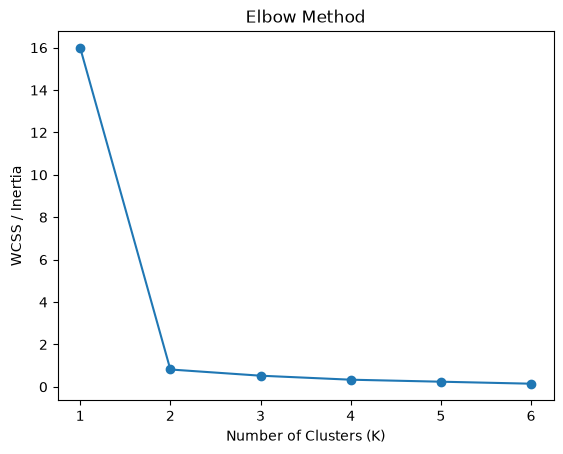

In [21]:
# Elbow Method
wcss = []

for k in range(1, 7):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)


plt.plot(range(1, 7), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
# K-Means Model
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)



In [23]:
# Cluster Labels
print("Cluster Labels:")
print(labels)


Cluster Labels:
[0 0 0 0 1 1 1 1]


In [24]:
# Centroids
print("\nCentroids:")
print(kmeans.cluster_centers_)



Centroids:
[[-0.9749135  -0.97332853]
 [ 0.9749135   0.97332853]]


In [25]:
# Inertia
print("\nWCSS / Inertia:")
print(kmeans.inertia_)




WCSS / Inertia:
0.8174020448775132


In [26]:
# Silhouette Score
score = silhouette_score(X_scaled, labels)

print("\nSilhouette Score:")
print(score)


Silhouette Score:
0.8162373271849019


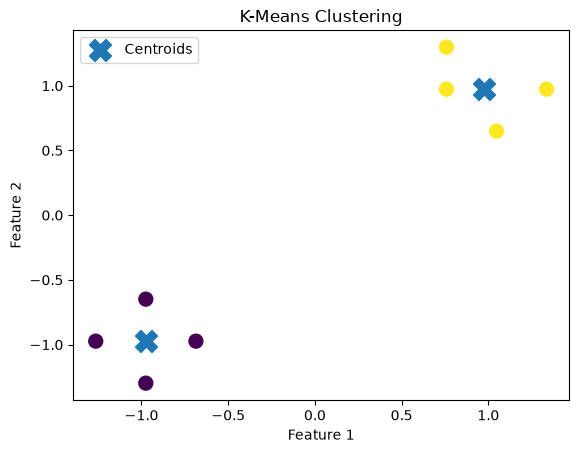

In [27]:
# Visualization
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    marker="X",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.legend()
plt.show()